In [1]:
# plot inline
%matplotlib inline

In [2]:
import os

import scanpy as sc
import datetime
import matplotlib.pyplot as plt
from matplotlib import style

In [3]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [4]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)


In [5]:
# mk dir
dir_name = f'/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle'
if not os.path.exists(dir_name):
    os.makedirs(dir_name)

In [6]:
# load data
adata = sc.read('/nfs/team361/am74/Cytomeister/configs/HSPC/epoch4/20250714-07:15_minference_adata_gNFE2_ssrc_tmask.h5ad')
full_data = sc.read('/lustre/scratch126/cellgen/lotfollahi/kl11/data/hspc/cd34.h5ad')

full_data = full_data[full_data.obs['diff_state']!='stem'].copy()

In [7]:
full_data.X = full_data.layers['counts']

In [8]:
# Only consider genes with more than 1 count
sc.pp.filter_genes(full_data, min_counts=1)
sc.pp.normalize_per_cell(full_data, key_n_counts='n_counts')

In [9]:

common_genes = full_data.var_names.intersection(adata.var_names)
full_data = full_data[:, common_genes].copy()

In [10]:
# # Select highly variable genes
filter_result = sc.pp.filter_genes_dispersion(full_data.X,
                                              flavor='cell_ranger',
                                              n_top_genes=3000,
                                              log=False)
# filter_result = None
# # add TF list as they should be kept for perturbation
with open('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/perturbgen/configs/eval/HSPC/perturb_TF.txt') as f:
    tf_list = f.read().splitlines()
tf_bool = full_data.var_names.isin(tf_list)

In [11]:
if filter_result is not None:
    all_genes = filter_result.gene_subset | tf_bool
    print('Number of genes after filtering and adding TFs:', sum(all_genes))
else:
    all_genes = list(set(full_data.var_names.to_list() + tf_list))
    print('Number of genes after adding TFs:', len(all_genes))

Number of genes after filtering and adding TFs: 3004


In [12]:
full_data = full_data[:, all_genes].copy()

In [13]:
# Renormalize after filtering
sc.pp.normalize_per_cell(full_data)
full_data.raw = full_data
full_data.layers["raw_count"] = full_data.raw.X.copy()

In [14]:
full_data.X[:10,:10]

<10x10 sparse matrix of type '<class 'numpy.float32'>'
	with 9 stored elements in Compressed Sparse Row format>

In [15]:
# log transform and scale
sc.pp.log1p(full_data)
sc.pp.scale(full_data)
# PCA
sc.tl.pca(full_data, svd_solver='arpack')


In [16]:
# Diffusion map
sc.pp.neighbors(full_data, n_neighbors=4, n_pcs=20)

sc.tl.diffmap(full_data)
# Calculate neihbors again based on diffusionmap
sc.pp.neighbors(full_data, n_neighbors=10, use_rep='X_diffmap')

In [17]:
# sc.tl.louvain(full_data, resolution=0.8)

In [18]:
full_data.obs

,runid_mrna_sample,assignment_id,age,mrna_samples,runid,sorting,runid_prot_samples,prot_samples,biological_replicate_labID,sex,...,phase,S_score,G2M_score,celltype_v1,leiden,celltype_v2,donor_tissue,age_group,diff_state,n_counts
AAAGAACCACTAGAGG-SLX19160_SIGAG7,SLX19160_SIGAG7,SLX-19160_SIGAG7_RBG31066_XN3392_CB-3,0.0,SIGAG7,SLX19160,CD34,SLX19160_RPI2,RPI2,RBG31066_XN3392,M,...,G1,-0.065054,-0.078769,Mo_DC,8,Mono pre./Mono,XN3392_CB_4_0y,Cord Blood,terminal,2852.306152
CCACAAACACGACAGA-SLX19160_SIGAG7,SLX19160_SIGAG7,SLX-19160_SIGAG7_RBG31066_XN3392_CB-3,0.0,SIGAG7,SLX19160,CD34,SLX19160_RPI2,RPI2,RBG31066_XN3392,M,...,G1,-0.099293,-0.030275,B,16,Immature B,XN3392_CB_4_0y,Cord Blood,terminal,1341.040527
GTCATTTAGAGCAGCT-SLX19160_SIGAG7,SLX19160_SIGAG7,SLX-19160_SIGAG7_RBG31066_XN3392_CB-1,0.0,SIGAG7,SLX19160,CD34,SLX19160_RPI2,RPI2,RBG31066_XN3392,M,...,S,0.031094,-0.094174,MEMP,7,MEMP,XN3392_CB_2_0y,Cord Blood,intermediate,1020.445740
CATTTCAGTCAACGCC-SLX19160_SIGAG7,SLX19160_SIGAG7,SLX-19160_SIGAG7_RBG31066_XN3392_CB-2,0.0,SIGAG7,SLX19160,CD34,SLX19160_RPI2,RPI2,RBG31066_XN3392,M,...,S,0.003324,-0.050643,BaEoMa,17,Ba/Eo/Ma prog.,XN3392_CB_3_0y,Cord Blood,terminal,876.467346
TATGTTCGTCACTACA-SLX19160_SIGAG7,SLX19160_SIGAG7,SLX-19160_SIGAG7_RBG31066_XN3392_CB-3,0.0,SIGAG7,SLX19160,CD34,SLX19160_RPI2,RPI2,RBG31066_XN3392,M,...,G1,-0.112692,-0.082663,Mo_DC,8,Mono pre./Mono,XN3392_CB_4_0y,Cord Blood,terminal,2635.193359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTGTGTCGCTAAAC-SLX21505_SITTE7,SLX21505_SITTE7,SLX21505_SITTE7_P181-BM-0,16.5,SITTE7,SLX21505,CD34,SLX21505_SIGAD12,SIGAD12,P181,F,...,G1,-0.230547,-0.114922,B-prog-II,1,Pro-B,P181_PBM_16.5y,Pediatric,terminal,1679.159180
CTCTGGTAGGTCACCC-SLX21505_SITTE7,SLX21505_SITTE7,SLX21505_SITTE7_P181-BM-0,16.5,SITTE7,SLX21505,CD34,SLX21505_SIGAD12,SIGAD12,P181,F,...,G1,-0.186310,-0.111143,B-prog-II,1,Pro-B,P181_PBM_16.5y,Pediatric,terminal,1817.906128
CATCCCAAGTCATGGG-SLX21505_SITTE7,SLX21505_SITTE7,SLX21505_SITTE7_P181-BM-0,16.5,SITTE7,SLX21505,CD34,SLX21505_SIGAD12,SIGAD12,P181,F,...,G1,-0.004105,-0.134199,pDC,14,pDC,P181_PBM_16.5y,Pediatric,terminal,1526.308716
TCAGTTTGTCCAGAAG-SLX21505_SITTE7,SLX21505_SITTE7,SLX21505_SITTE7_P181-BM-0,16.5,SITTE7,SLX21505,CD34,SLX21505_SIGAD12,SIGAD12,P181,F,...,S,0.574120,0.143871,B-prog-I,11,Cycling pro-B,P181_PBM_16.5y,Pediatric,terminal,1449.420288


In [19]:
# PAGA graph construction
sc.tl.paga(full_data, groups='celltype_v2')

In [20]:
plt.rcParams["figure.figsize"] = [6, 4.5]

<Axes: >

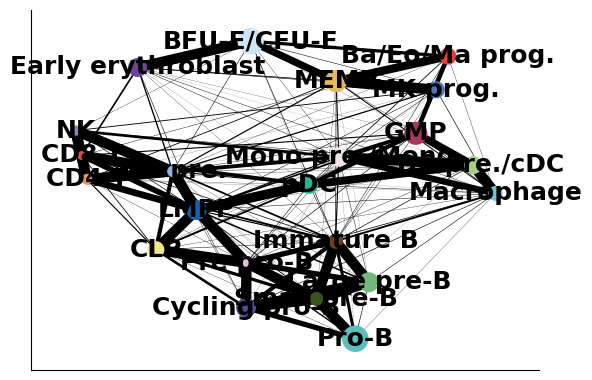

In [21]:
sc.pl.paga(full_data, show=False)
plt.savefig(f'{dir_name}/paga_graph.pdf', dpi=300)

In [22]:
sc.tl.draw_graph(full_data, init_pos='paga', random_state=123)

<Axes: title={'center': 'celltype_v2'}, xlabel='FA1', ylabel='FA2'>

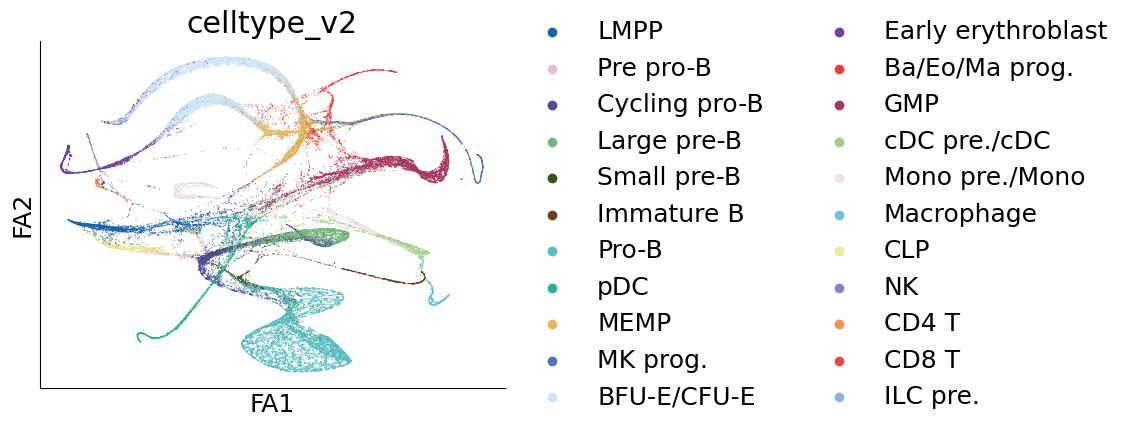

In [23]:
sc.pl.draw_graph(full_data, color='celltype_v2', show=False)
#save
plt.savefig(f'{dir_name}/umap_celltype.pdf', dpi=300, bbox_inches='tight')

In [ ]:
# # save preprocessing
full_data.write(f'{dir_name}/full_data_3k.h5ad')